# Simulation — Realistic Scenarios

## Setup

In [ ]:
#| label: setup
#| include: false

# For CFA population models
source(here::here("Scripts", "DataAppendixScripts", "models.R"))

# For DRY (Don't repeat yourself) parameters
source(here::here("Scripts", "DataAppendixScripts", "helpers.R"))

# For simulations caching
source(here::here("Scripts", "DataAppendixScripts", "cache_utils.R"))

# For loading existing simulations cache
source(here::here("Scripts", "DataAppendixScripts", "cache_loader.R"))

# Load existing simulations cache if available (cache_loader.R)
cache_load_existing()

## Scenario A — Missing data (MCAR 10%)

Missingness reduces effective sample size and inflates sampling variance, both of which reduce power relative to the ideal scenario. When data are missing completely at random (MCAR), this reduction is a function of the missing proportion alone, and Full Information Maximum Likelihood (FIML) provides consistent estimates without imputation \[@enders2023; @simsem2021\].

The two chunks below replicate the main misspecification simulation with 10% MCAR applied to both the reference and the alternative conditions. Using the same population and analysis models as before isolates the power cost of missingness, since all other design choices remain constant.

In [ ]:
#| label: sim-missing-popmodel

popmodel_miss <- cache_or_run("popmodel_miss", {
    sim(
        NULL,                  # Number of replications is defined by SEQ1
        n = SEQ1,              # Sample sizes defined in SEQ1 (see helpers.R)
        pmMCAR = P_MCAR,       # 10% missing completely at random (see helpers.R)
        analyzemodel,          # Model used for analysis (see models.R)
        generate = popmodel,   # Reference population model (see models.R)
        std.lv = TRUE,         # Standardized latent variables
        lavaanfun = "cfa",     # Use CFA function from lavaan
        estimator = "ml",      # ML estimator
        missing = "fiml",      # FIML missing-data handling
        seed = SEED,           # Seed for reproducibility (see helpers.R)
        multicore = TRUE       # Use multicore processing
    )
})

In [ ]:
#| label: sim-missing-h1model

h1model_miss <- cache_or_run("h1model_miss", {
    sim(
        NULL,                  # Number of replications is defined by SEQ1
        n = SEQ1,              # Sample sizes defined in SEQ1 (see helpers.R)
        pmMCAR = P_MCAR,       # 10% missing completely at random (see helpers.R)
        analyzemodel,          # Model used for analysis (see models.R)
        generate = h1model,    # Alternative (misspecified) population model (see models.R)
        std.lv = TRUE,         # Standardized latent variables
        lavaanfun = "cfa",     # Use CFA function from lavaan
        estimator = "ml",      # ML estimator
        missing = "fiml",      # FIML missing-data handling
        seed = SEED,           # Seed for reproducibility (see helpers.R)
        multicore = TRUE       # Use multicore processing
    )
})

### Power curves for fit indices

The power curves below follow the same logic as in the ideal scenario, but with cutoff distributions now derived from samples subject to 10% MCAR. The expected outcome is a rightward shift in the curves: the same target power level requires a larger $N$ than under complete data \[@enders2023; @feng2023\].

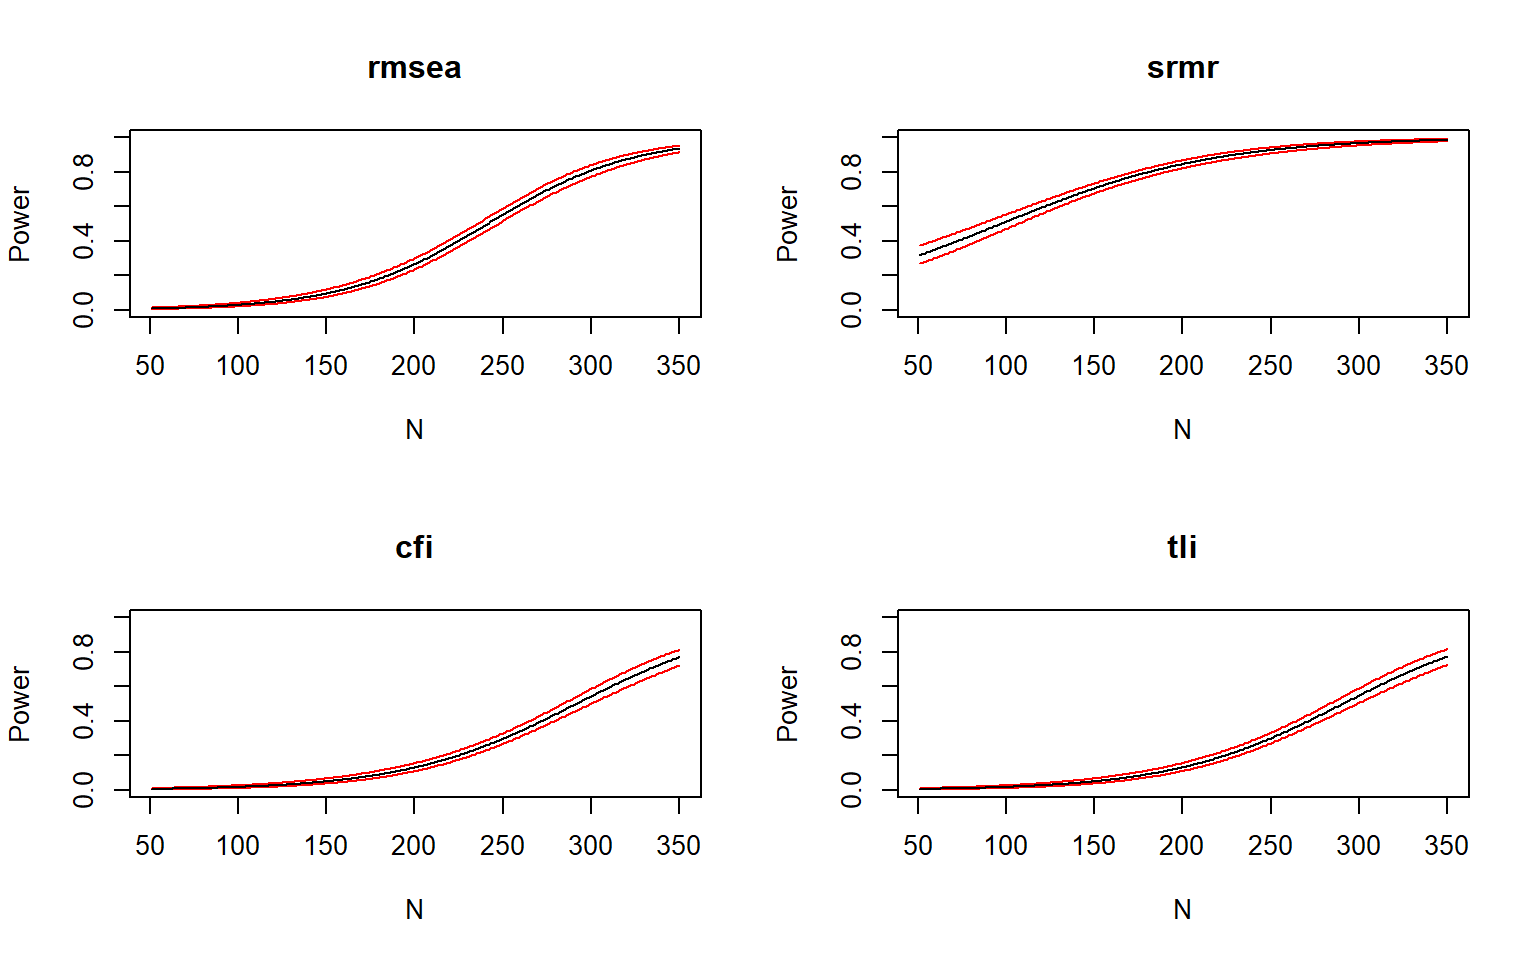

In [ ]:
#| label: fig-power-curve-missing
#| fig-cap: "Power curves for fit indices under missing data conditions."
#| fig-width: 8
#| fig-height: 5

plotPowerFit(
    h1model_miss,     # Data simulated under H1 (with cross-loadings)
    popmodel_miss,    # Data simulated under H0 (reference model)
    alpha = ALPHA,    # Significance level for determining power (see helpers.R)
    usedFit = FITS    # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

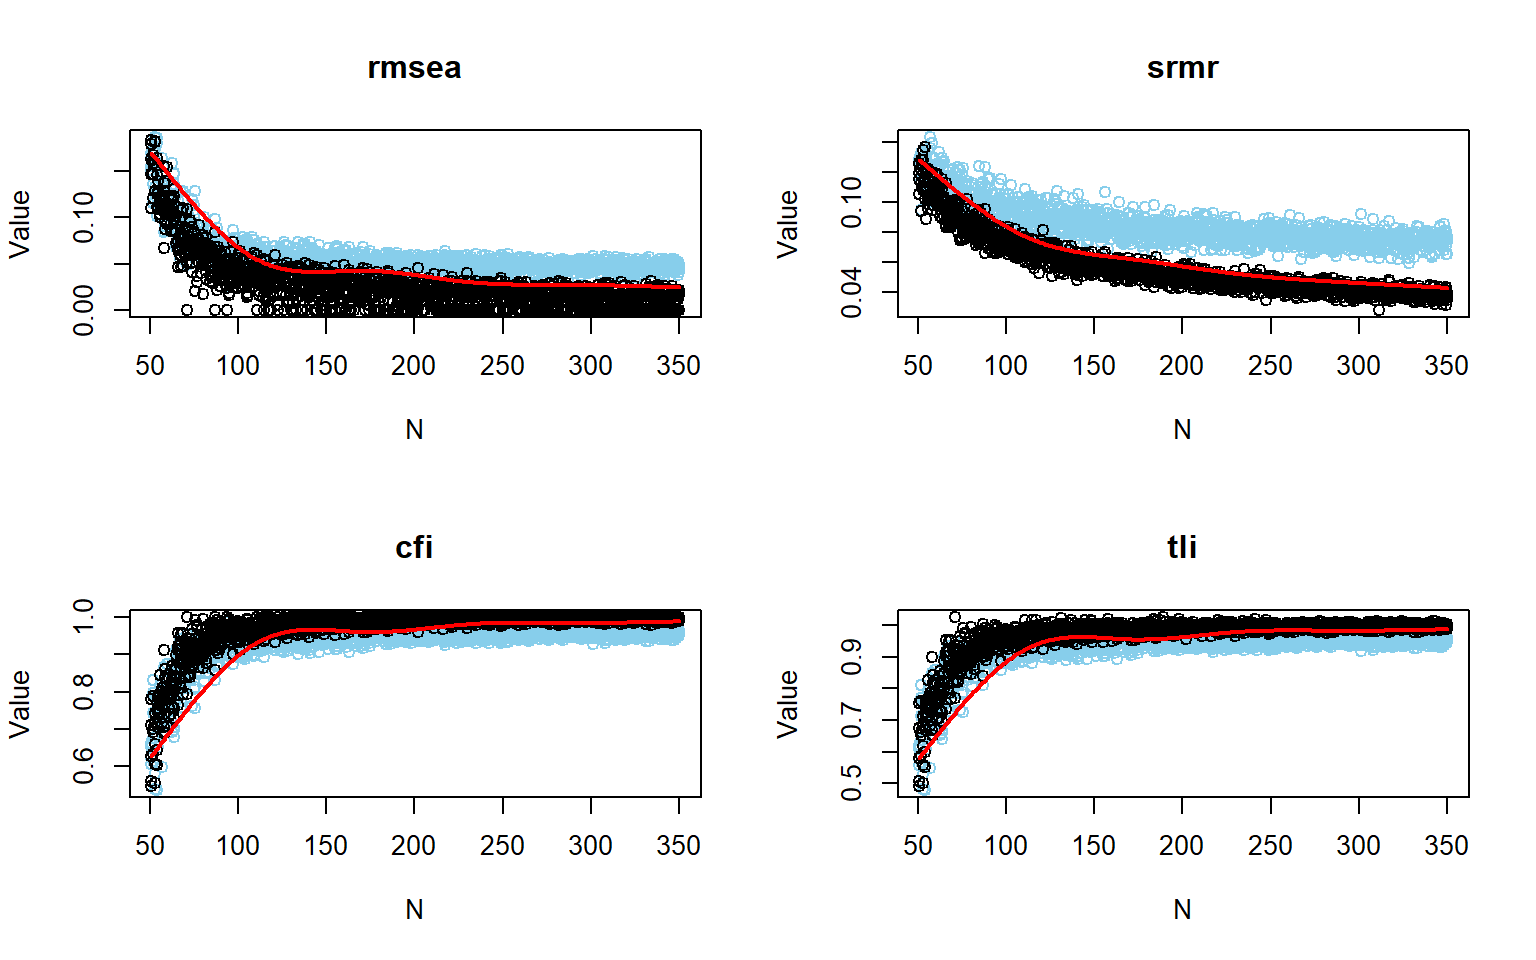

In [ ]:
#| label: fig-fit-curve-missing
#| fig-cap: "Power curves for fit indices under missing data conditions without logistic smoothing."
#| fig-width: 8
#| fig-height: 5

plotPowerFit(
    h1model_miss,     # Data simulated under H1 (with cross-loadings)
    popmodel_miss,    # Data simulated under H0 (no cross-loadings)
    alpha = ALPHA,    # Significance level for determining power (see helpers.R)
    usedFit = FITS,   # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
    logistic = FALSE  # Display raw simulated points and cutoff lines instead of logistic curves
)

### Power and cutoff values for fit indices

`getPowerFit()` and `getCutoff()` are evaluated here at $N = 359$, the minimum sample size at which all four indices reached the target power under this missing-data condition. Reading power alongside the empirical cutoffs makes it possible to verify that the decision rule itself is well-calibrated — not merely that the rejection rate is high at the chosen $N$ \[@jobst2023; @wang2023\].

In [ ]:
#| label: tbl-power-cutoff-missing
#| tbl-cap: "Power and fit index cutoff values under missing data conditions at N = 359."

# Estimate power for rejecting the misspecified model (h1model_miss)
# using fit-index cutoffs implied by the null model (popmodel_miss) at alpha = ALPHA and N = 359.
power_miss <- getPowerFit(
    h1model_miss,                 # Data simulated under H1 (with cross-loadings)
    nullObject = popmodel_miss,   # Data simulated under H0 (no cross-loadings)
    alpha = ALPHA,                # Significance level for determining power (see helpers.R)
    nVal = 359,                   # Sample size for analysis
    usedFit = FITS                # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Derive empirical cutoff values for the selected fit indices
# from the reference-model sampling distribution under the same conditions.
cutoff_miss <- getCutoff(
    popmodel_miss,                # Data simulated under H0 (no cross-loadings)
    alpha = ALPHA,                # Significance level for determining power (see helpers.R)
    nVal = 359,                   # Sample size for analysis
    usedFit = FITS                # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Combine power and cutoff values into a compact summary table.
power_cutoff_miss <- rbind(
    "Power" = as.numeric(power_miss),
    "Cutoff" = as.numeric(cutoff_miss[1, ])
)

# Standardize column names for presentation.
colnames(power_cutoff_miss) <- toupper(names(power_miss)) 

# Print the table.
knitr::kable(power_cutoff_miss, digits = 3, align = "c") 

            RMSEA   SRMR     CFI     TLI
  -------- ------- ------- ------- -------
  Power     0.947   0.987   0.802   0.806
  Cutoff    0.011   0.035   1.008   1.010


## Scenario B — Non-normality

Non-normal continuous indicators are common in psychometric research, particularly when items use ordered response scales or when the construct exhibits floor or ceiling effects. Under non-normality, standard ML standard errors and test statistics are generally biased, so Satorra-Bentler scaling (MLR) is applied here to maintain appropriate Type I error control.

The `dist` object in `helpers.R` generates data with mild skewness (ranging from $-1$ to $+1$) and slight excess kurtosis (from $1$ to $2$), a range that is realistic for quality-of-life scales such as the WHOQOL-BREF \[@mosqueirataipe2026\]. The goal is not to impose severe distributional violations, but to verify that the power conclusions from the ideal scenario hold under plausible real-world deviations from normality.

In [ ]:
#| label: sim-nnorm-popmodel

popmodel_nnorm <- cache_or_run("popmodel_nnorm", {
    sim(
        NULL,                    # Number of replications is defined by SEQ1              
        n = SEQ1,                # Sample sizes defined in SEQ1 (see helpers.R)
        analyzemodel,            # Model used for analysis (see models.R)
        generate = popmodel,     # Population model (see models.R)
        indDist = dist,          # Distribution used for simulation (see helpers.R)
        std.lv = TRUE,           # Standardized latent variables
        lavaanfun = "cfa",       # Use CFA function from lavaan
        estimator = "mlr",       # MLR estimator for non-normal data
        seed = SEED,             # Seed for reproducibility (see helpers.R)
        multicore = TRUE         # Use multicore processing
    )
})

In [ ]:
#| label: sim-nnorm-h1model

h1model_nnorm <- cache_or_run("h1model_nnorm", {
    sim(
        NULL,                    # Number of replications is defined by SEQ1              
        n = SEQ1,                # Sample sizes defined in SEQ1 (see helpers.R)
        analyzemodel,            # Model used for analysis (see models.R)
        generate = h1model,      # Population model with cross-loadings (see models.R)
        indDist = dist,          # Distribution used for simulation (see helpers.R)
        std.lv = TRUE,           # Standardized latent variables
        lavaanfun = "cfa",       # Use CFA function from lavaan
        estimator = "mlr",       # MLR estimator for non-normal data
        seed = SEED,             # Seed for reproducibility (see helpers.R)
        multicore = TRUE         # Use multicore processing
    )
})

### Power curves for fit indices

As in the ideal scenario, power is evaluated against empirical cutoffs derived from the null-model sampling distribution, now obtained under MLR estimation. This keeps the decision criterion consistent with the data conditions and avoids applying cutoffs calibrated under normality to non-normal simulated data \[@mcneish2021; @simsem2021\].

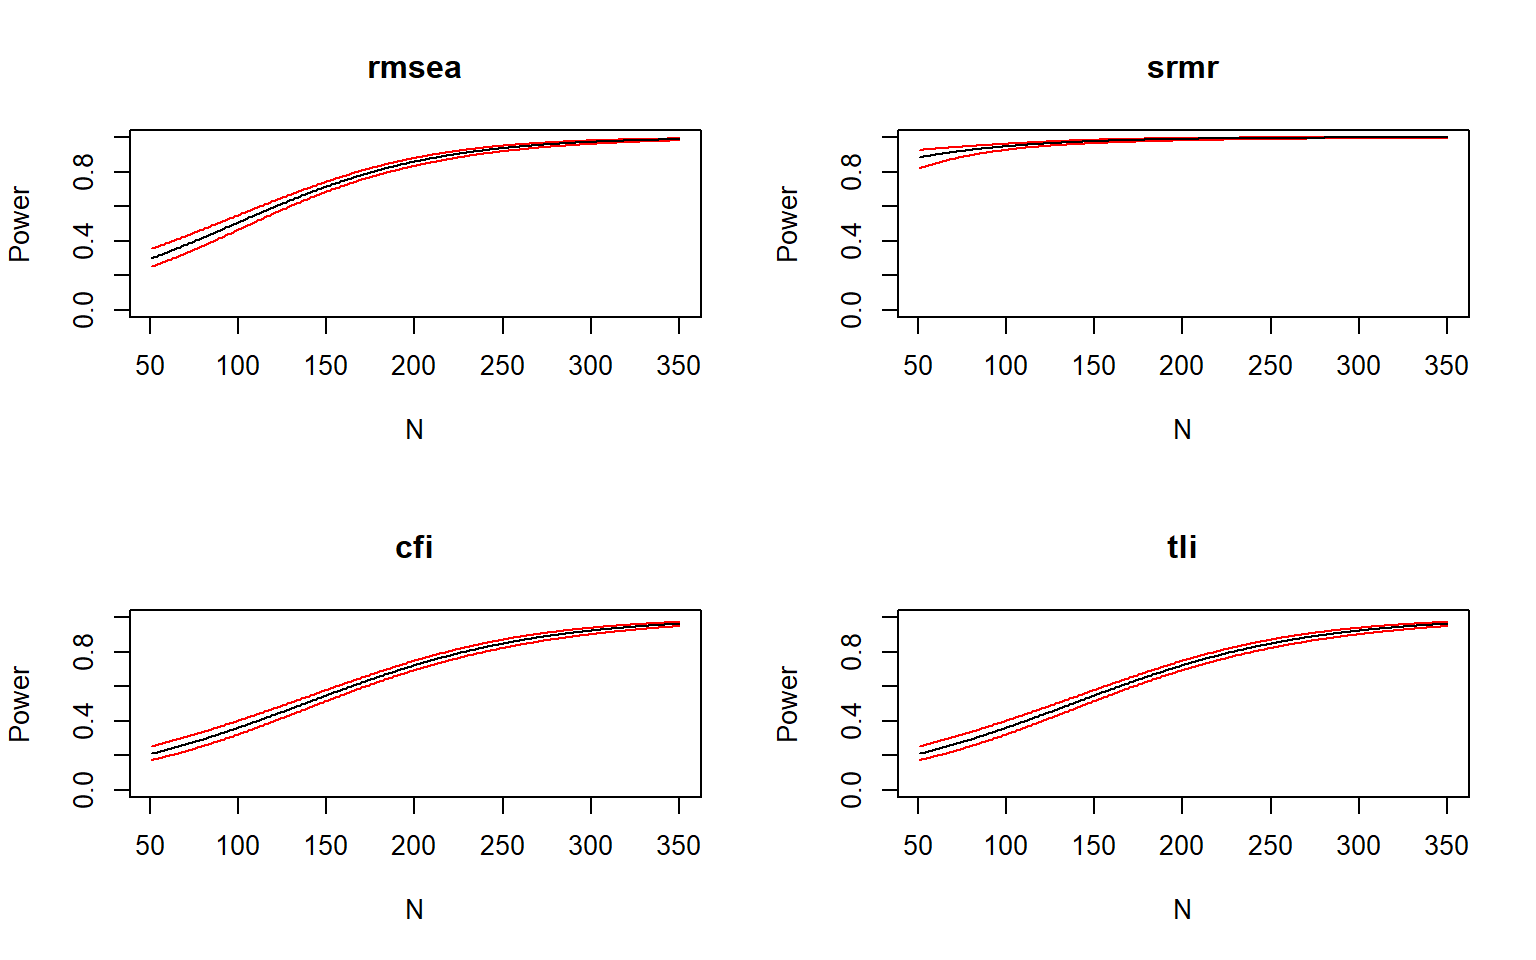

In [ ]:
#| label: fig-power-curve-nnorm
#| fig-cap: "Power curves for fit indices under non-normal conditions."
#| fig-width: 8
#| fig-height: 5

plotPowerFit(
  h1model_nnorm,   # Data simulated under H1 (with cross-loadings)
  popmodel_nnorm,  # Data simulated under H0 (no cross-loadings)
  alpha = ALPHA,   # Significance level for determining power (see helpers.R)
  usedFit = FITS   # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

The unsmoothed version below displays the raw separation between reference and alternative fit-index distributions across sample sizes, which helps assess at what point the two conditions become empirically distinguishable \[@simsem2021; @mcneish2021\].

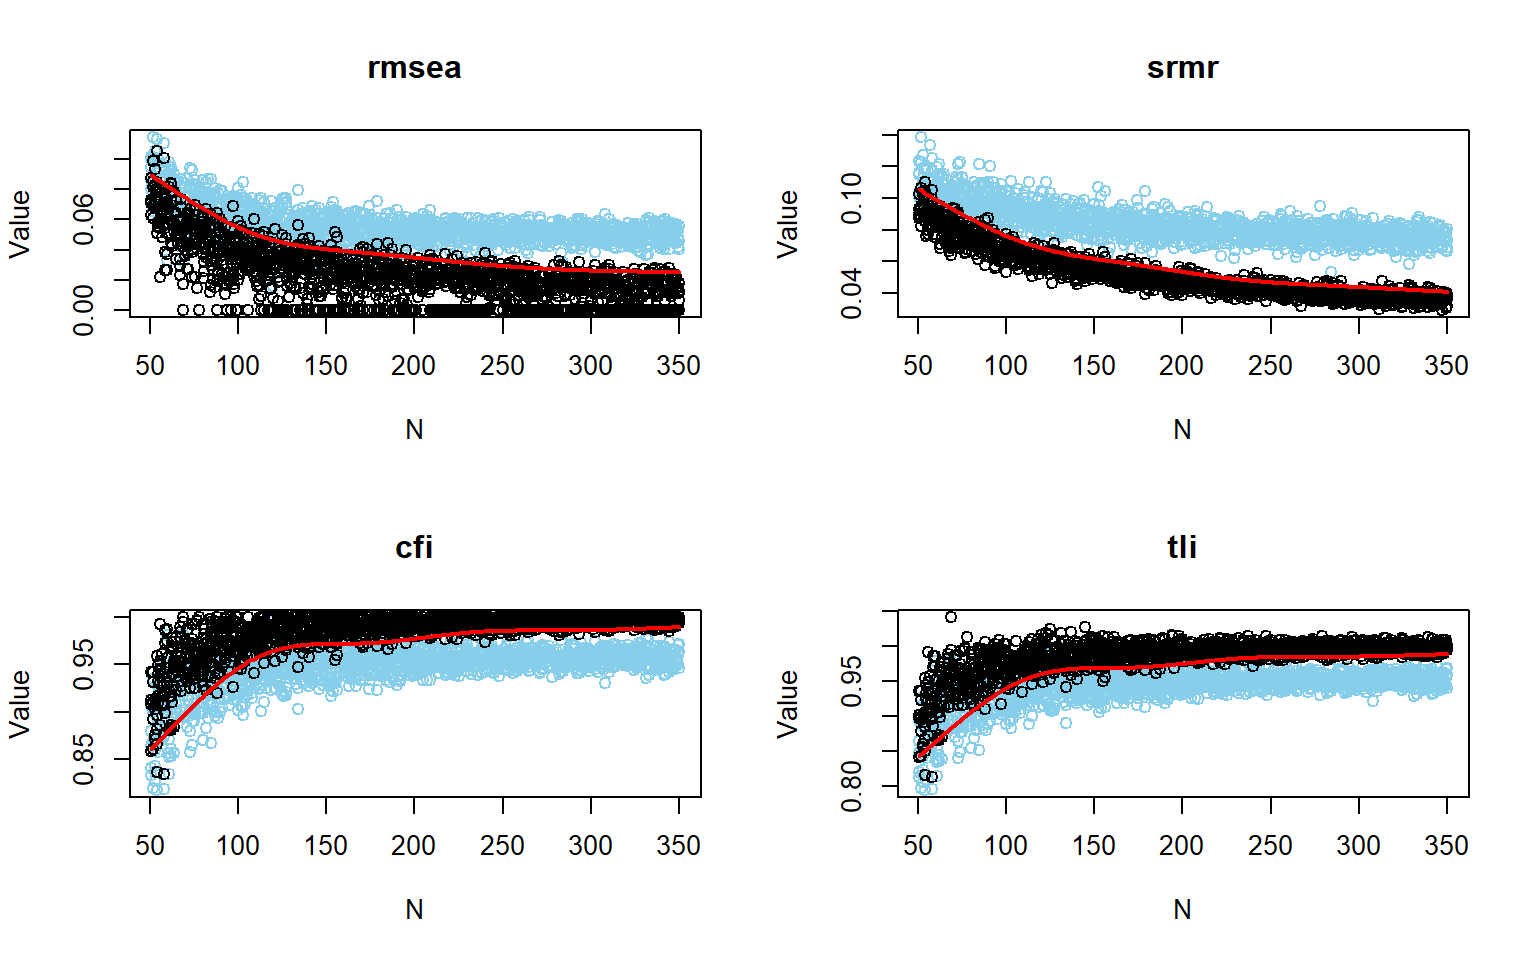

In [ ]:
#| label: fig-fit-curve-nnorm
#| fig-cap: "Power curves for fit indices under non-normal conditions without logistic smoothing."
#| fig-width: 8
#| fig-height: 5

plotPowerFit(
  h1model_nnorm,   # Data simulated under H1 (with cross-loadings)
  popmodel_nnorm,  # Data simulated under H0 (no cross-loadings)
  alpha = ALPHA,   # Significance level for determining power (see helpers.R)
  usedFit = FITS,  # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
  logistic = FALSE # Display raw simulated points and cutoff lines instead of logistic curves
)

### Power and cutoff values for fit indices

At $N = 228$, the table below summarizes power and empirical cutoffs under mild non-normality. Comparing these values with the ideal-scenario results at $N = 231$ shows the net effect of the distributional deviation: if power and cutoff values remain close across the two conditions, the conclusions from the ideal scenario are robust to this degree of non-normality \[@feng2023\].

In [ ]:
#| label: tbl-power-cutoff-nnorm
#| tbl-cap: "Power and fit index cutoff values under non-normal conditions at N = 228."

# Estimate power for rejecting the misspecified model (h1model_nnorm)
# using fit-index cutoffs implied by the null model (popmodel_nnorm) at alpha = ALPHA and N = 228.
power_nnorm <- getPowerFit(
  h1model_nnorm,               # Data simulated under H1 (with cross-loadings)
  nullObject = popmodel_nnorm, # Data simulated under H0 (no cross-loadings)
  alpha = ALPHA,               # Significance level for determining power (see helpers.R)
  nVal = 228,                  # Sample size for analysis
  usedFit = FITS               # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Derive empirical cutoff values for the selected fit indices
# from the null-model sampling distribution under the same conditions.
cutoff_nnorm <- getCutoff(
  popmodel_nnorm,              # Data simulated under H0 (no cross-loadings)
  alpha = ALPHA,               # Significance level for determining power (see helpers.R)
  nVal = 228,                  # Sample size for analysis
  usedFit = FITS               # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Combine power and cutoff values into a compact summary table.
power_cutoff_nnorm <- rbind(
  "Power" = as.numeric(power_nnorm),
  "Cutoff" = as.numeric(cutoff_nnorm[1, ])
)

# Standardize column names for presentation.
colnames(power_cutoff_nnorm) <- toupper(names(power_nnorm))

# Print the table.
knitr::kable(power_cutoff_nnorm, digits = 3, align = "c")

            RMSEA   SRMR     CFI    TLI
  -------- ------- ------- ------- ------
  Power     0.91    0.994   0.800   0.80
  Cutoff    0.04    0.059   0.964   0.96
